In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from sklearn.datasets import make_classification

In [5]:
x,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False, class_sep=20)

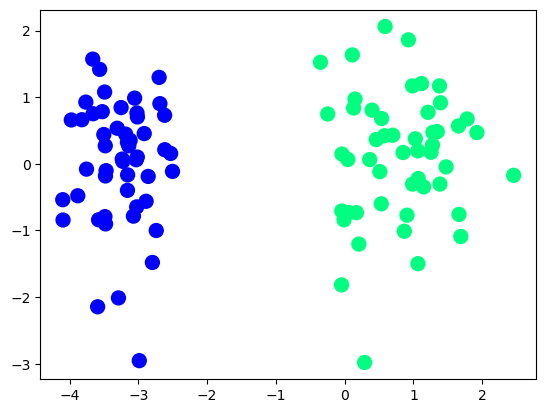

In [12]:
plt.scatter(x[:,0],x[:,1],c=y,cmap="winter",s=100)
plt.show()

In [17]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression(penalty=None,solver="sag")
LR.fit(x,y)

C:\Users\heman\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [19]:
print(LR.coef_)
print(LR.intercept_)

[[4.78360512 0.20790278]]
[5.75245438]


In [20]:
m1 = -(LR.coef_[0][0]/LR.coef_[0][1])
b1 = -(LR.intercept_/LR.coef_[0][1])

In [21]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [22]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [54]:
def gd(x,y):
    x=np.insert(x,0,1,axis=1)
    weights=np.ones(x.shape[1])
    lr=0.5

    for i in range(5000):
        y_hat=sigmoid(np.dot(x,weights))
        weights=weights + lr* (np.dot((y-y_hat),x)/x.shape[0])

    return weights[1:],weights[0]


In [55]:
coef_,intercept_=gd(x,y)

In [56]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [57]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

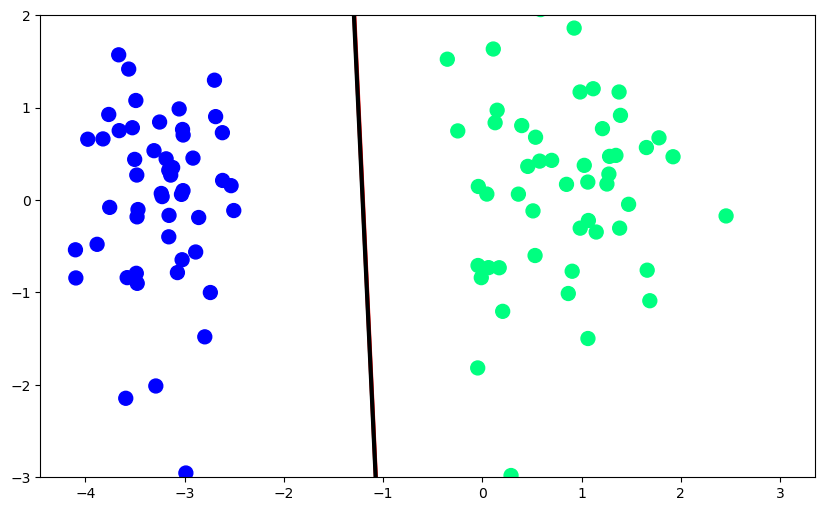

In [58]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show()